# **Figure 1 I: Pericyte resting potential across tissue preparations**

In [5]:
from fig_utils import *

set_style()
# enable_saving()  # ← uncomment to save all figures to their save_path
%matplotlib inline

## Resting membrane potential by preparation type

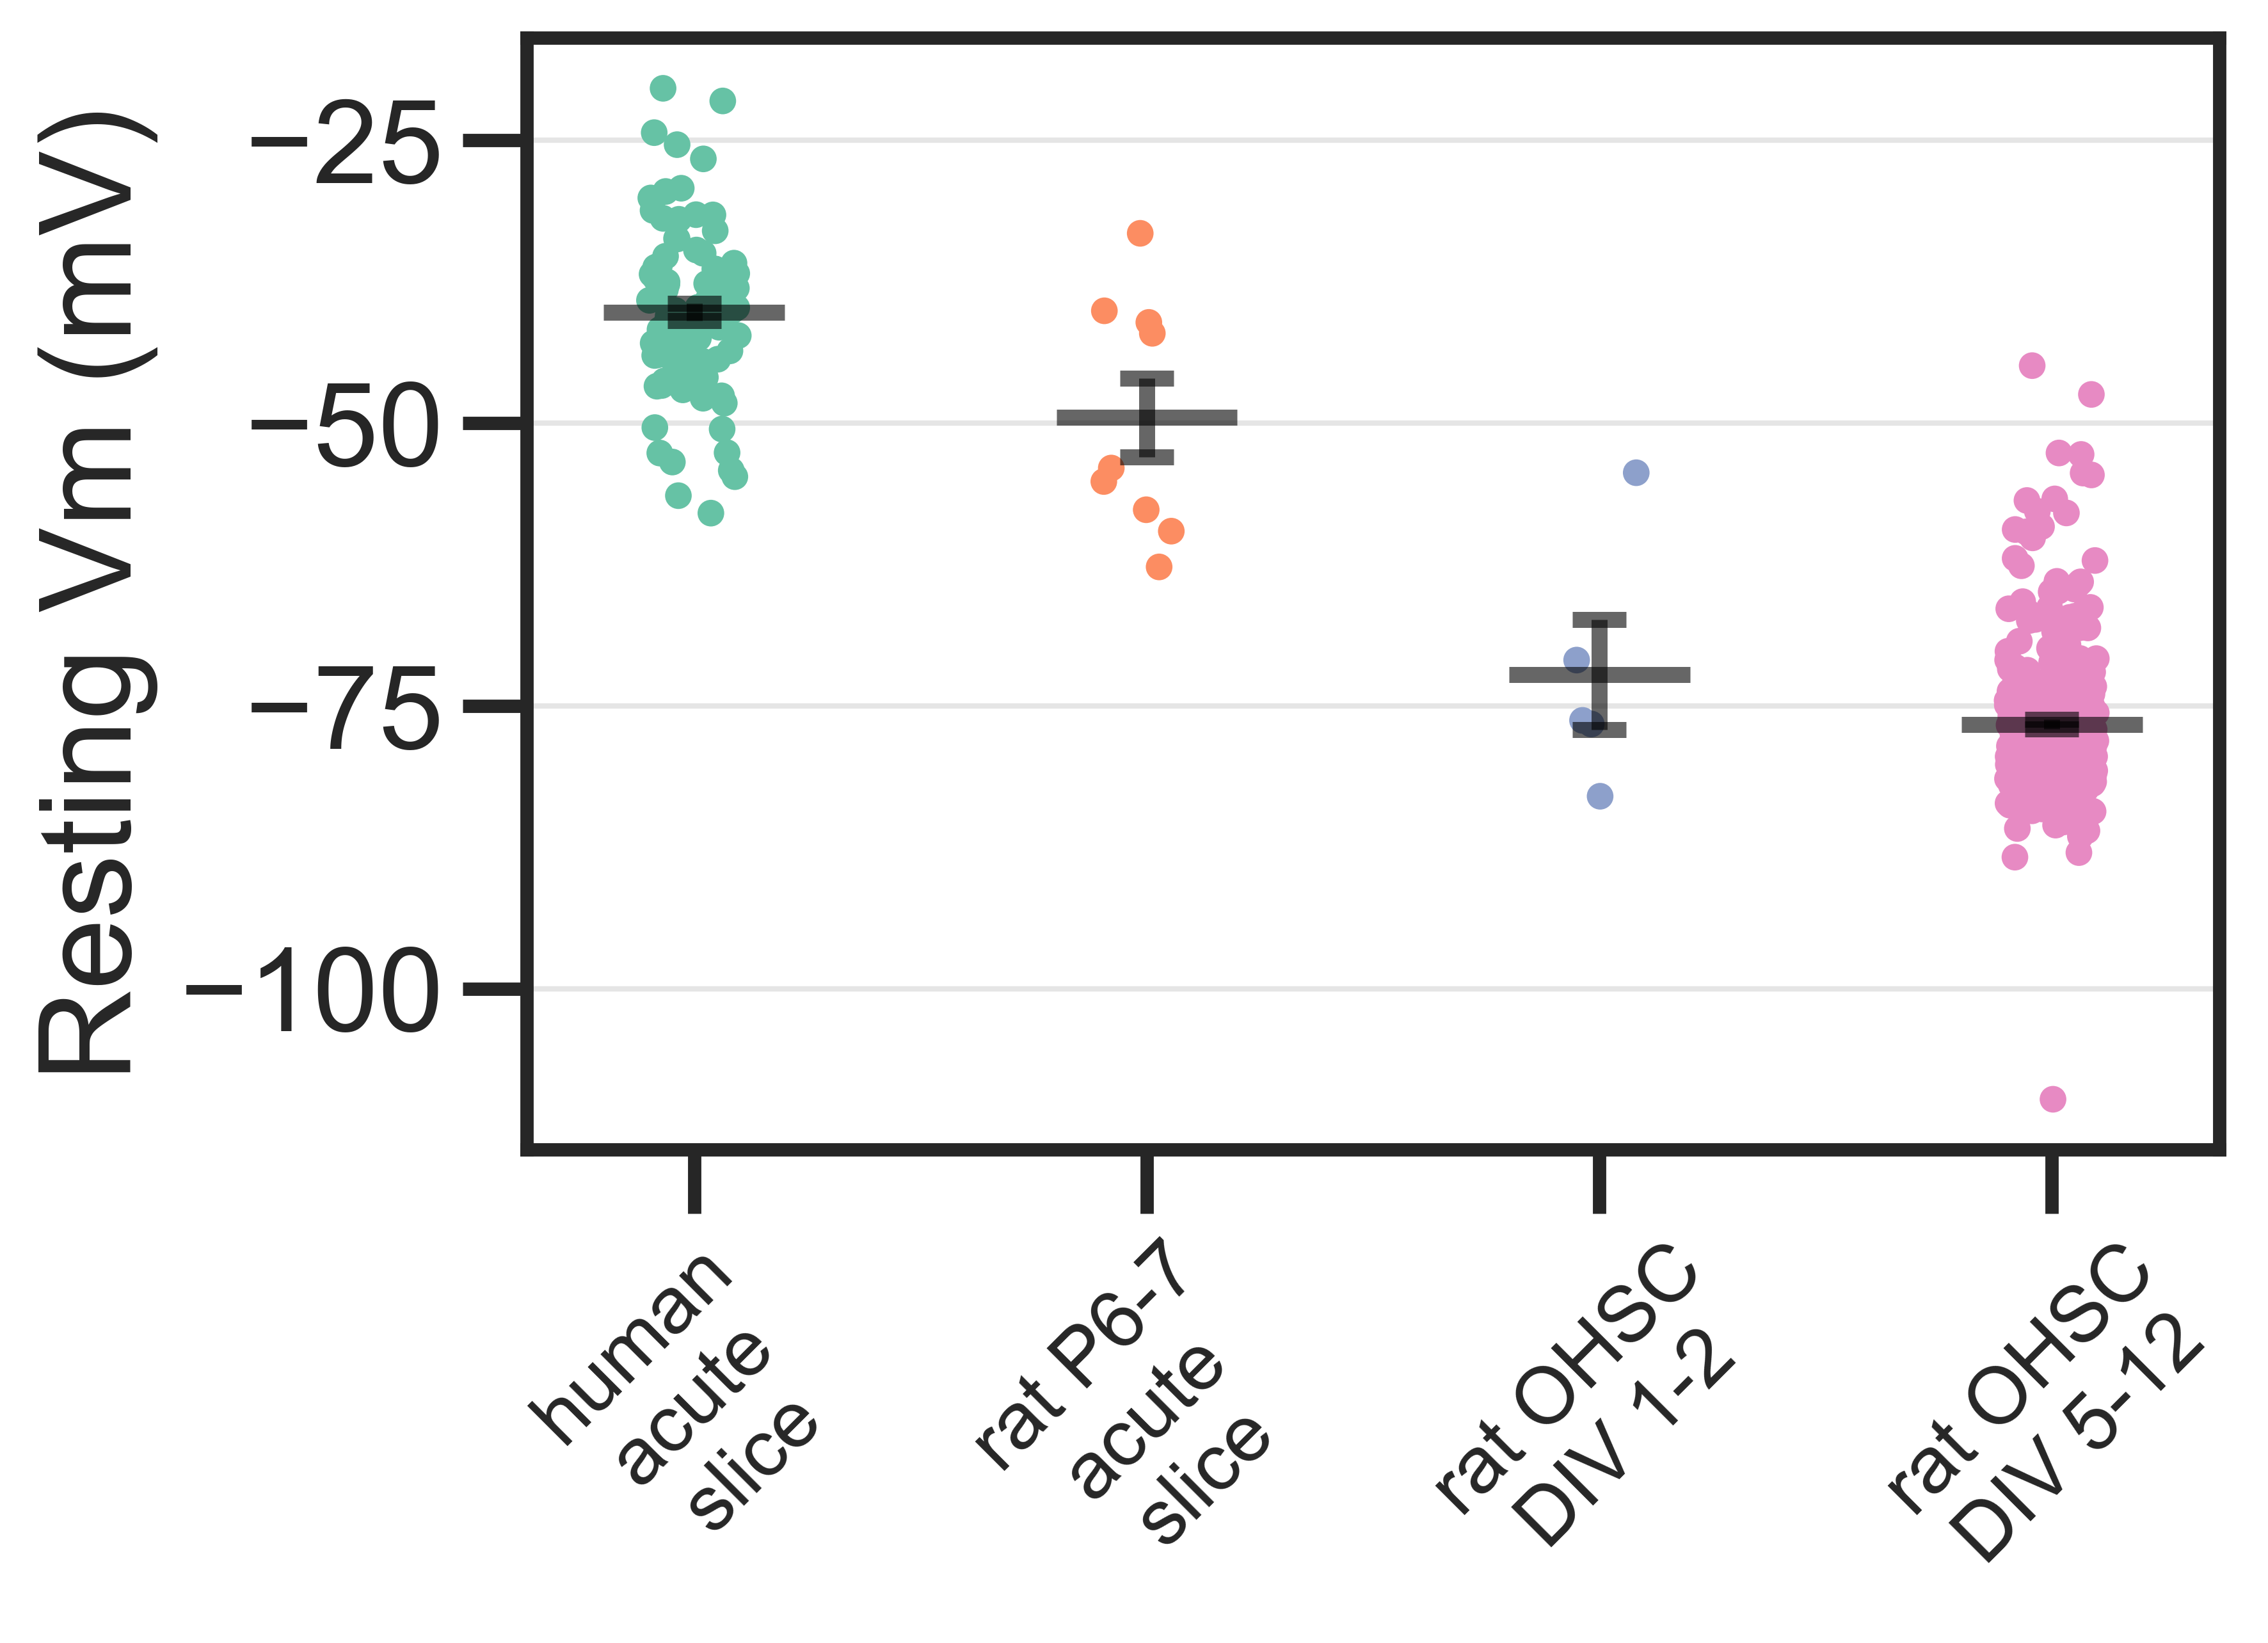

In [16]:
# Load data
df = pd.read_csv('./data_tables/Resting_Differences_OHSC_Acute_Slice_Human.csv')

# Strip plot: resting Vm across tissue preparations
sns.set_style('ticks')
sns.set_context('poster')

fig, ax = plt.subplots(dpi=DEFAULT_DPI)
plt.grid(True, linestyle='-', linewidth=1, alpha=0.5)

np.random.seed(42)
sns.stripplot(x="condition", y="I=0 Median", data=df, palette="Set2",
              zorder=1, hue="condition", legend=False, ax=ax)

# Mean ± SEM horizontal bars per group
categories = df['condition'].unique()
means = df.groupby('condition')['I=0 Median'].mean()
sems = df.groupby('condition')['I=0 Median'].sem()

for idx, cat in enumerate(categories):
    ax.hlines(means[cat], idx - 0.2, idx + 0.2,
              colors='black', linestyles='solid', alpha=0.6, zorder=2)
    ax.errorbar(idx, means[cat], yerr=sems[cat], fmt='none', ecolor='black',
                capsize=5, capthick=3, elinewidth=3, alpha=0.6, zorder=2)

# X-axis labels
ticks = ['human\nacute\nslice', 'rat P6-7\nacute\nslice',
         'rat OHSC\nDIV 1-2', 'rat OHSC\nDIV 5-12']
ax.set_xticks(np.arange(len(categories)))
ax.set_xticklabels(ticks, fontsize=15, rotation=45, va='top')
ax.set_ylabel("Resting Vm (mV)")
ax.set_xlabel("")

plt.tight_layout()
save_if_enabled("Pericytes_resting_acute_vs_culture.svg")
plt.show()